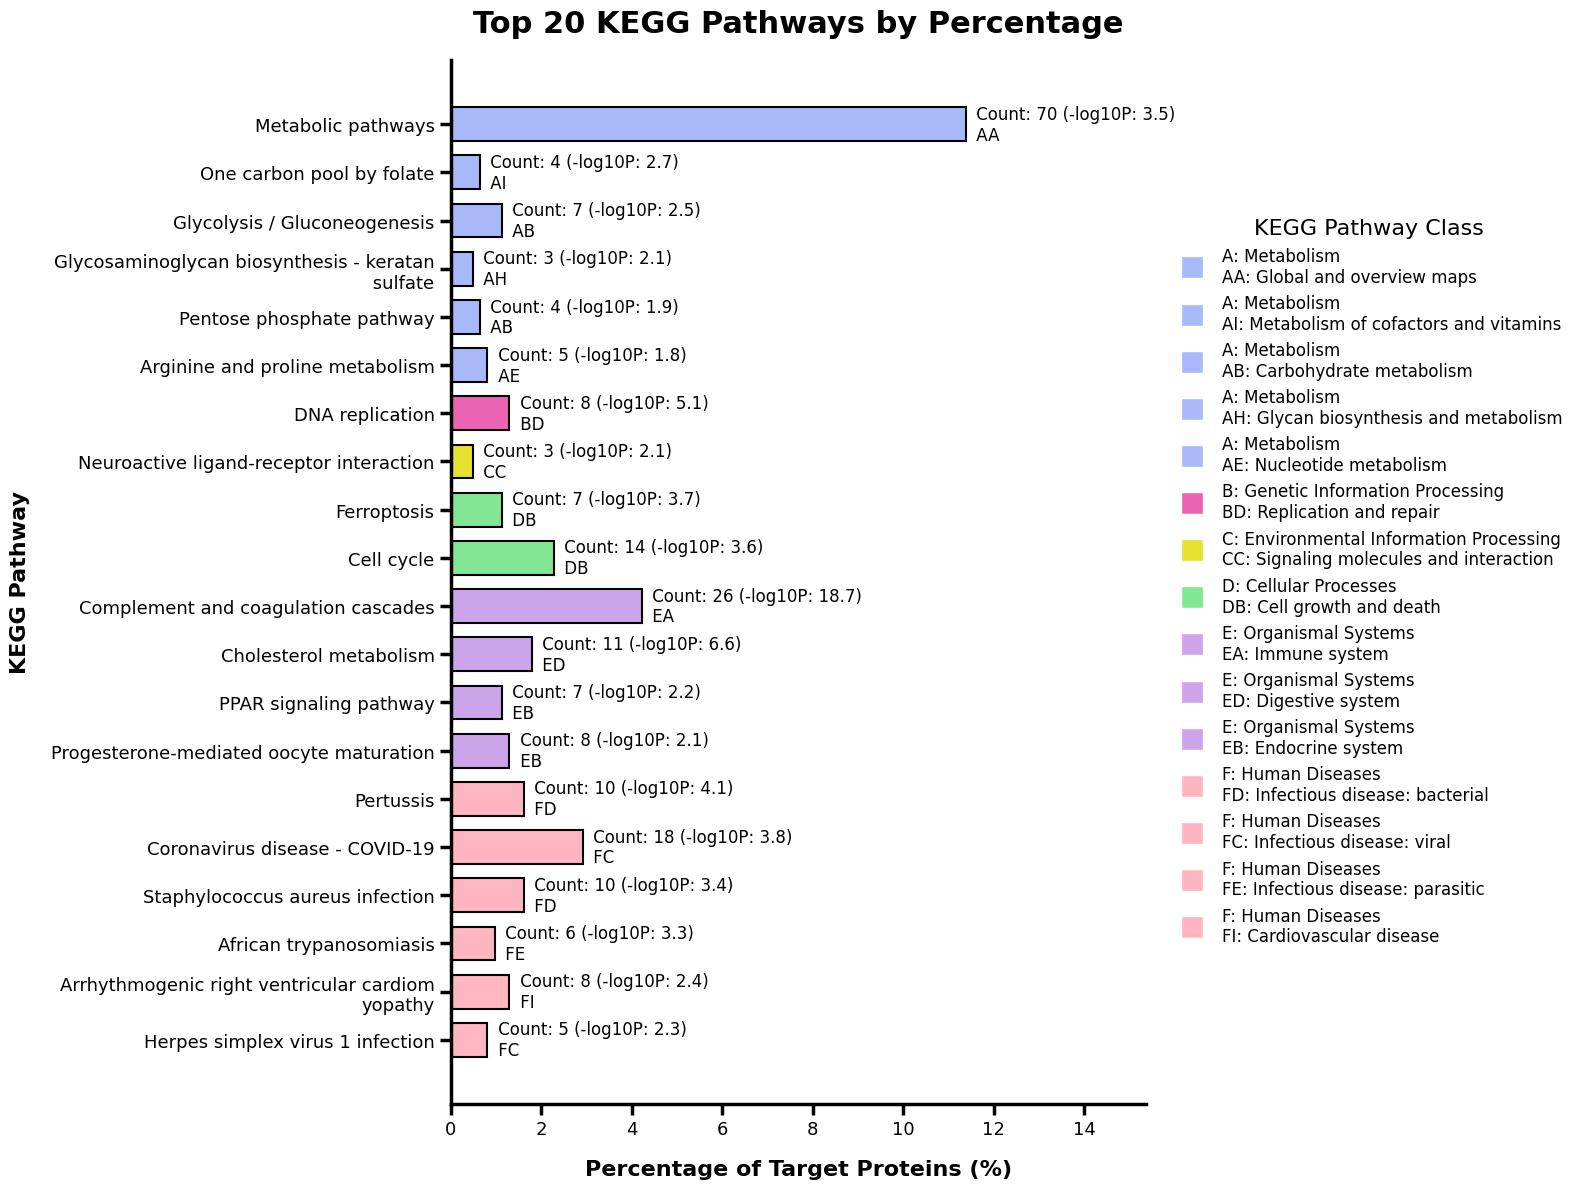

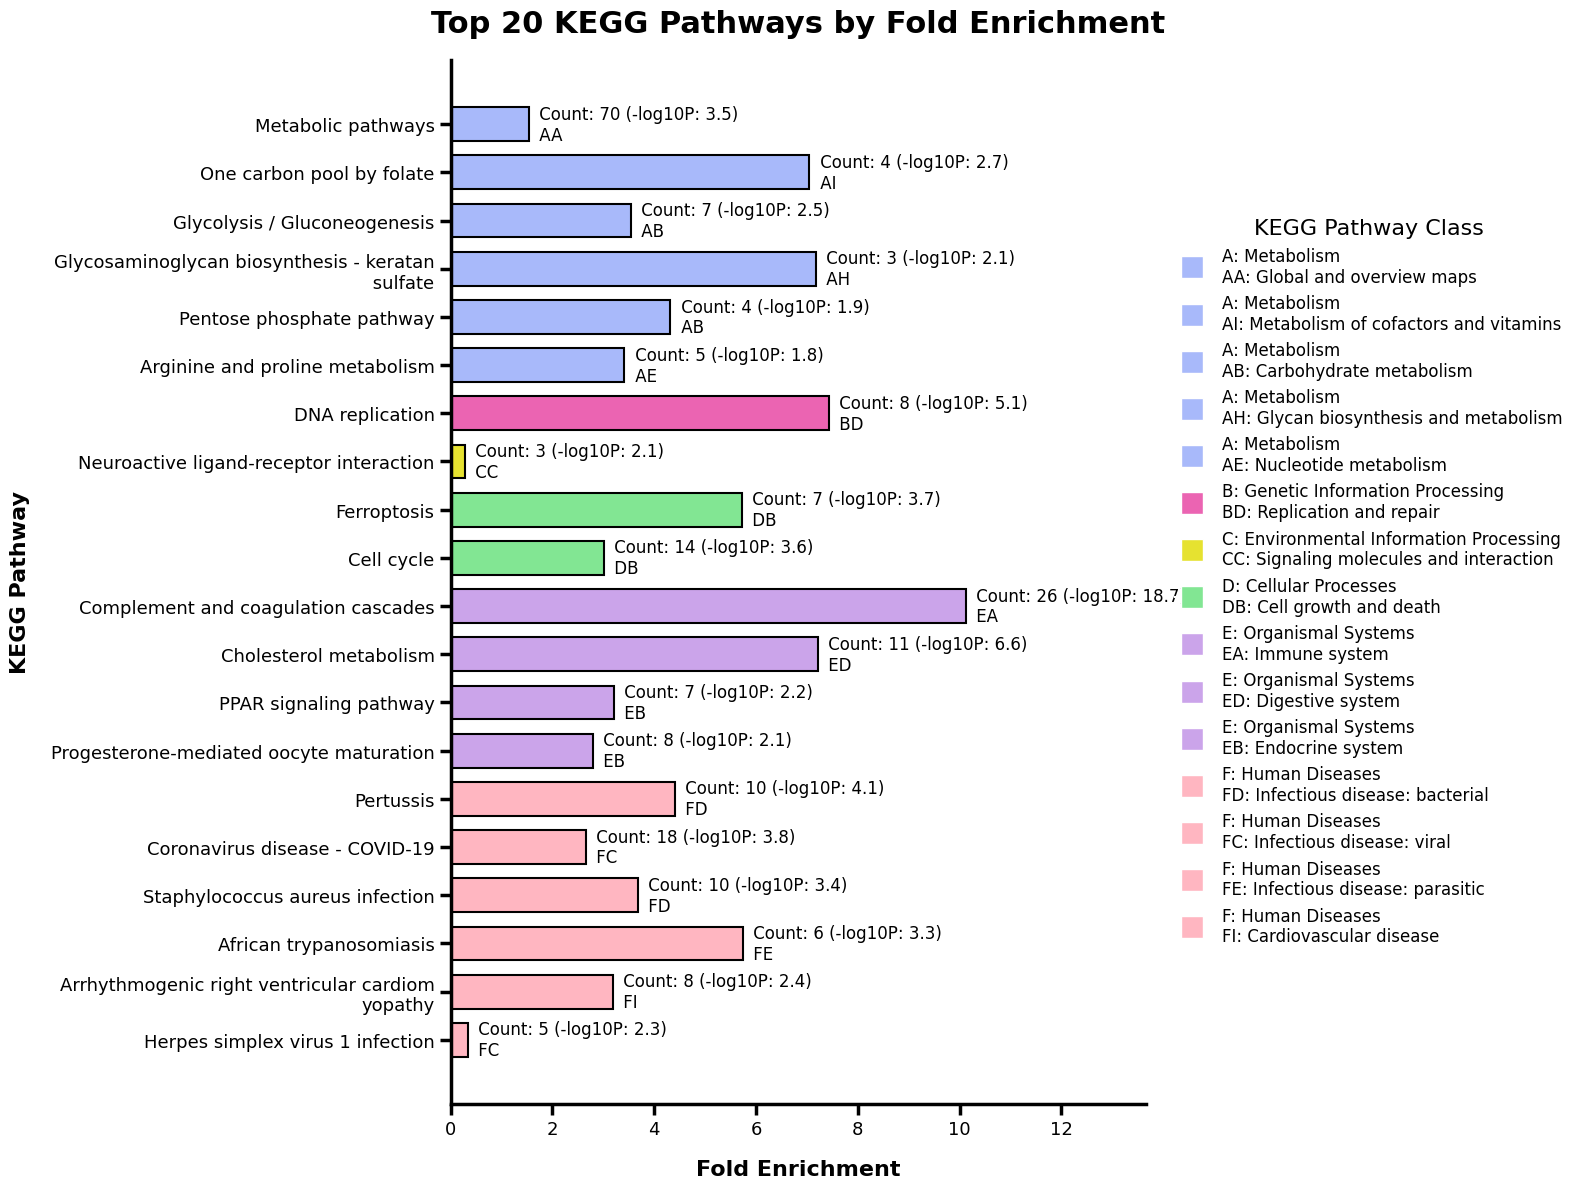

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==================== 第 1 步：设置路径与分类字典 ====================
# 替换为你的真实 KEGG 富集结果 CSV 路径
file_path = r"E:\python-pro\ICA\组学分析\danbai_data\raw data\20241107-CQT2024101111-F001-4D Direct DIA定量蛋白组-分析报告\20241107-CQT2024101111-F001-4D Direct DIA定量蛋白组-分析报告\4.Diff_Bioinformatics\2.KEGG_Enrichment\ABs_vs_dABs\ABs_vs_dABs_KEGG_Enrichment.csv"

# 定义七大类的标准颜色映射（莫兰迪柔和色系，适合发文）
category_colors = {
    'A': '#A8B9FA',  # Metabolism (代谢)
    'B': '#EB64B2',  # Genetic Information Processing (遗传)
    'C': '#E6E230',  # Environmental Information Processing (环境)
    'D': '#82E693',  # Cellular Processes (细胞过程)
    'E': '#CBA4EA',  # Organismal Systems (有机体系统)
    'F': '#FFB6C1',  # Human Diseases (人类疾病, 替换为安全的十六进制粉色)
    'G': '#FFD700'   # Drug Development (药物开发)
}

# 一级分类标准全称
category_descriptions = {
    'A': 'Metabolism',
    'B': 'Genetic Information Processing',
    'C': 'Environmental Information Processing',
    'D': 'Cellular Processes',
    'E': 'Organismal Systems',
    'F': 'Human Diseases',
    'G': 'Drug Development'
}

# ==================== 第 2 步：读取与清洗数据 ====================
data = pd.read_csv(file_path)

# 清除可能存在的首尾空格
data['tier1.abbr'] = data['tier1.abbr'].astype(str).str.strip()
data['tier2.abbr'] = data['tier2.abbr'].astype(str).str.strip()

# 强制转换 P-Value 为数值
data['P-Value'] = pd.to_numeric(data['P-Value'], errors='coerce')

# 排除宽泛的全局代谢通路 (通常这些通路包含成百上千个蛋白，缺乏具体指示意义)
exclude_pathways = ["01100", "01110", "01120", "map01100", "map01110", "map01120"]
filtered_data = data[~data['KEGG Pathway'].isin(exclude_pathways)].dropna(subset=['P-Value']).copy()

# 核心筛选逻辑：优先 < 0.05，不够3个则放宽到 < 0.1
temp_data = filtered_data[filtered_data['P-Value'] < 0.05]
if len(temp_data) < 3:
    temp_data = filtered_data[filtered_data['P-Value'] < 0.1]

# 取 Top 20 并计算 -log10(P-Value)
top_20 = temp_data.sort_values(by='P-Value').head(20).copy()
top_20['-log10P'] = -np.log10(top_20['P-Value'])

# 【关键排序】按一级分类(A->G)升序排，再按 P-Value 升序排，保证同类别的柱子完美聚拢
top_20_sorted = top_20.sort_values(by=['tier1.abbr', 'P-Value'], ascending=[True, True])

# 解析 Test Ratio (把 "15/300" 转化为 0.05)
def parse_ratio(x):
    try:
        if isinstance(x, str) and '/' in x:
            num, den = x.split('/')
            return float(num) / float(den)
        return float(x)
    except:
        return 0.0

top_20_sorted['Ratio Val'] = top_20_sorted['Test Ratio'].apply(parse_ratio)
top_20_sorted['Percent'] = top_20_sorted['Ratio Val'] * 100

# 构建二级分类名称字典 (提取原表中的 tier2 描述)
tier2_descriptions = dict(zip(data['tier2.abbr'], data['tier2']))

def wrap_text(text, width=40):
    """文本自动换行，防止Y轴文字太长顶出画布"""
    text = str(text)
    return '\n'.join([text[i:i+width] for i in range(0, len(text), width)])

top_20_sorted['Wrapped Name'] = top_20_sorted['Pathway Description'].apply(wrap_text)

# ==================== 第 3 步：提取不重复的图例信息 ====================
unique_legend_pairs = top_20_sorted[['tier1.abbr', 'tier2.abbr']].drop_duplicates()
legend_elements = []

for _, row in unique_legend_pairs.iterrows():
    t1 = row['tier1.abbr']
    t2 = row['tier2.abbr']
    t1_desc = category_descriptions.get(t1, 'Unknown Category')
    t2_desc = tier2_descriptions.get(t2, t2)
    
    # 图例文字格式： A: Metabolism \n 1.1: Carbohydrate metabolism
    label_text = f"{t1}: {t1_desc}\n{t2}: {t2_desc}"
    legend_elements.append(
        plt.Line2D([0], [0], marker='s', color='w', label=label_text, 
                   markerfacecolor=category_colors.get(t1, '#CCCCCC'), markersize=16)
    )

# ==================== 第 4 步：绘制图 1 (X轴为占比 Percentage) ====================
plt.figure(figsize=(16, 12))
ax1 = plt.gca()

# 为每根柱子分配对应 A-G 类别的颜色
colors1 = [category_colors.get(tier, '#CCCCCC') for tier in top_20_sorted['tier1.abbr']]

bars1 = ax1.barh(top_20_sorted['Wrapped Name'], top_20_sorted['Percent'], 
                 color=colors1, edgecolor='black', height=0.7, linewidth=1.5)

# 图表边框与刻度美化
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_linewidth(2.5)
ax1.spines['left'].set_linewidth(2.5)
ax1.tick_params(width=2.5, length=8, labelsize=13)

# X轴延长空间，给右侧的文字标签留出位置
max_pct = top_20_sorted['Percent'].max()
ax1.set_xlim(0, max_pct * 1.35)

# 在柱子右侧添加文字标签 (Count, P值, 二级分类)
for bar, (_, row) in zip(bars1, top_20_sorted.iterrows()):
    label_str = f" Count: {row['Test Count']} (-log10P: {row['-log10P']:.1f})\n {row['tier2.abbr']}"
    ax1.text(bar.get_width() + (max_pct * 0.01), bar.get_y() + bar.get_height() / 2,
             label_str, va='center', fontsize=12, color='black')

ax1.set_xlabel("Percentage of Target Proteins (%)", fontsize=16, fontweight='bold', labelpad=15)
ax1.set_ylabel("KEGG Pathway", fontsize=16, fontweight='bold', labelpad=15)
plt.title("Top 20 KEGG Pathways by Percentage", fontsize=22, fontweight='bold', pad=20)

# 反转Y轴：让 A 类（代谢）排在图表最顶端，符合常规视觉顺序
ax1.invert_yaxis()

# 放置图例于图表右侧外部
ax1.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5), 
           title="KEGG Pathway Class", title_fontsize=16, prop={'size': 12}, frameon=False)

plt.tight_layout()
plt.show()

# ==================== 第 5 步：绘制图 2 (X轴为 Fold Enrichment) ====================
plt.figure(figsize=(16, 12))
ax2 = plt.gca()

bars2 = ax2.barh(top_20_sorted['Wrapped Name'], top_20_sorted['Fold Enrich'], 
                 color=colors1, edgecolor='black', height=0.7, linewidth=1.5)

# 图表边框与刻度美化
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_linewidth(2.5)
ax2.spines['left'].set_linewidth(2.5)
ax2.tick_params(width=2.5, length=8, labelsize=13)

# X轴延长空间
max_fe = top_20_sorted['Fold Enrich'].max()
ax2.set_xlim(0, max_fe * 1.35)

# 在柱子右侧添加文字标签
for bar, (_, row) in zip(bars2, top_20_sorted.iterrows()):
    label_str = f" Count: {row['Test Count']} (-log10P: {row['-log10P']:.1f})\n {row['tier2.abbr']}"
    ax2.text(bar.get_width() + (max_fe * 0.01), bar.get_y() + bar.get_height() / 2,
             label_str, va='center', fontsize=12, color='black')

ax2.set_xlabel("Fold Enrichment", fontsize=16, fontweight='bold', labelpad=15)
ax2.set_ylabel("KEGG Pathway", fontsize=16, fontweight='bold', labelpad=15)
plt.title("Top 20 KEGG Pathways by Fold Enrichment", fontsize=22, fontweight='bold', pad=20)

# 反转Y轴
ax2.invert_yaxis()

# 放置同样的图例
ax2.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5), 
           title="KEGG Pathway Class", title_fontsize=16, prop={'size': 12}, frameon=False)

plt.tight_layout()
plt.show()